In [179]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns

Carga:

In [180]:
df_churn = pd.read_csv("./churn_ext_2.csv")
df_churn

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [181]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [182]:
df_churn['Tipo de Tarjeta'] = df_churn['Tipo de Tarjeta'].fillna('Desconocido')

KeyError: 'Tipo de Tarjeta'

In [183]:

le_Tneg = LabelEncoder()
le_LDeu = LabelEncoder()
le_Titar = LabelEncoder()
Le_ToTar = LabelEncoder()
Mi_Activ = LabelEncoder()
le_ciu = LabelEncoder()
le_prov = LabelEncoder()

df_churn['Gender'] = le_Tneg.fit_transform(df_churn['Gender'])
df_churn['Subscription Type'] = le_LDeu.fit_transform(df_churn['Subscription Type'])
df_churn['Contract Length'] = le_Titar.fit_transform(df_churn['Contract Length'])


In [ ]:
le_Tneg = LabelEncoder()
le_LDeu = LabelEncoder()
le_Titar = LabelEncoder()
Le_ToTar = LabelEncoder()
Mi_Activ = LabelEncoder()
le_ciu = LabelEncoder()
le_prov = LabelEncoder()

df_churn['Tipo de Negocio'] = le_Tneg.fit_transform(df_churn['Tipo de Negocio'])
df_churn['Nivel de Deuda'] = le_LDeu.fit_transform(df_churn['Nivel de Deuda'])
df_churn['Tiene Tarjeta'] = le_Titar.fit_transform(df_churn['Tiene Tarjeta'])
df_churn['Tipo de Tarjeta'] = Le_ToTar.fit_transform(df_churn['Tipo de Tarjeta'])
df_churn['Miembro Abandono'] = Mi_Activ.fit_transform(df_churn['Miembro Abandono'])
df_churn['Ciudad'] = le_ciu.fit_transform(df_churn['Ciudad'])
df_churn['Provincia'] = le_prov.fit_transform(df_churn['Provincia'])


In [163]:
print(le_Tneg.classes_)
print(le_LDeu.classes_)
print(le_Titar.classes_)
print(Le_ToTar.classes_)
print(Mi_Activ.classes_)
#print(le_ciu.classes_)


['Female' 'Male']
['Basic' 'Premium' 'Standard']
['Annual' 'Monthly' 'Quarterly']


AttributeError: 'LabelEncoder' object has no attribute 'classes_'

In [184]:
#Y_data_churn = df_churn['Miembro Abandono']
#X_data_churn = df_churn.drop(columns=['Miembro Abandono','Usuario','ID'])

Y_data_churn = df_churn['Churn']
X_data_churn = df_churn.drop(columns=['CustomerID','Churn'])

In [185]:
display(Y_data_churn.sample(5))
display(X_data_churn.sample(5))

7376     1
15270    0
2872     0
6681     1
25550    1
Name: Churn, dtype: int64

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
23900,37,0,23,22,0,16,2,2,462,29
38094,49,1,56,7,6,29,0,1,453,20
35927,47,1,23,22,10,1,0,1,253,20
25539,19,1,27,8,8,22,0,0,983,13
3015,31,1,26,6,9,12,0,0,728,16


Feature Selection

In [186]:
# Calculamos ANOVA F-value
f_scores, p_values = f_classif(X_data_churn, Y_data_churn)

# Creamos un DataFrame para ver los resultados claramente
res = pd.DataFrame({
    'Variable': X_data_churn.columns,
    'F_Score': f_scores,
    'p_value': p_values
}).sort_values(by='p_value', ascending=True)

# Normalmente, si el p_value es < 0.05, la relación es estadísticamente significativa

print(res)
best_var = res['Variable'].head(10).tolist()
print(best_var)
X_data_churn_filtrado = X_data_churn[best_var]

            Variable       F_Score        p_value
1             Gender   1791.457882   0.000000e+00
2             Tenure   2553.385793   0.000000e+00
4      Support Calls   6584.800249   0.000000e+00
5      Payment Delay  29012.627215   0.000000e+00
3    Usage Frequency    864.224640  1.048577e-188
8        Total Spend    402.904012   2.414280e-89
0                Age    260.260288   1.961525e-58
7    Contract Length     18.823193   1.436306e-05
6  Subscription Type      3.854354   4.962132e-02
9   Last Interaction      0.511200   4.746225e-01
['Gender', 'Tenure', 'Support Calls', 'Payment Delay', 'Usage Frequency', 'Total Spend', 'Age', 'Contract Length', 'Subscription Type', 'Last Interaction']


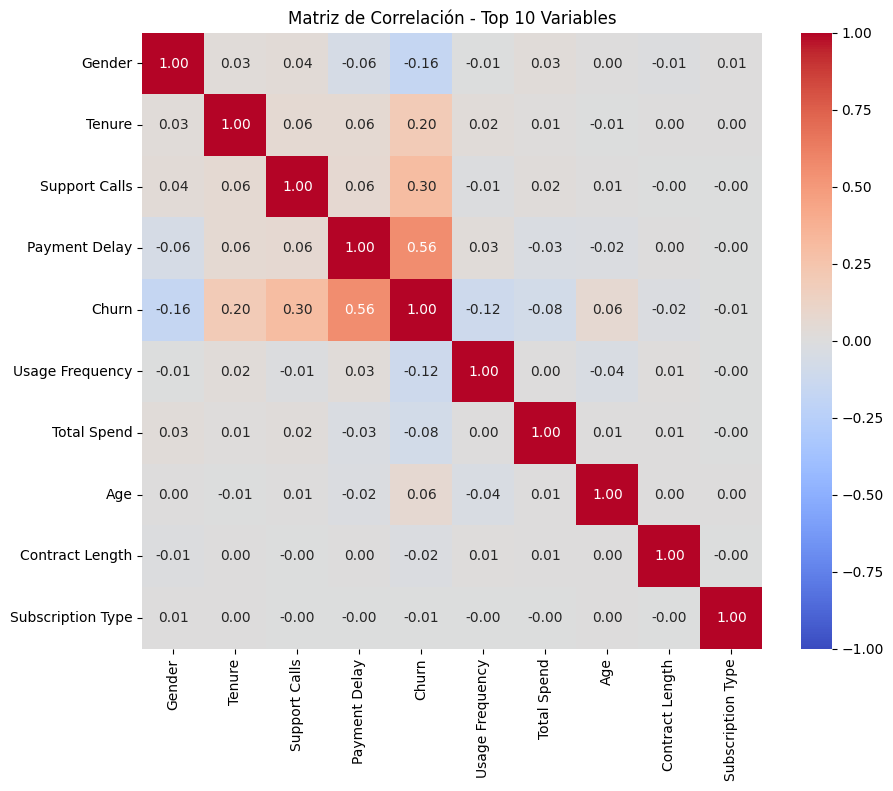

In [171]:
matriz_corr = X_data_churn_filtrado.corr()

# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Generamos un mapa de calor (heatmap)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación - Top 10 Variables")
plt.show()

XGBoost

In [5]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

Explainable con shap:

In [187]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 1. Calcular el peso para la clase minoritaria (Churn = 1)
conteo_clases = Y_data_churn.value_counts()
peso_positivos = conteo_clases[0] / conteo_clases[1] 

# 2. Configurar StratifiedKFold 
# Nota: Reduje n_splits a 5. Con 10 pliegues y 27 combinaciones, 
# entrenarías 270 modelos, lo que puede tomar mucho tiempo.
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 3. Inicializar el modelo base SOLO con los parámetros fijos
modelo_xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=peso_positivos,
    random_state=42
)

# 4. Crear el diccionario de hiperparámetros a explorar (Grid)
param_grid = {
    'n_estimators': [100, 200, 150, 300],
    'learning_rate': [0.05,0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

# 5. Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=modelo_xgb_base,
    param_grid=param_grid,
    cv=skf,
    scoring=['roc_auc', 'f1'], # Calculamos ambas métricas
    refit='roc_auc',           # XGBoost elegirá los mejores parámetros basándose en el AUC más alto
    n_jobs=-1,
    verbose=2 # Nivel 2 muestra el progreso de cada combinación
)

# 6. Ejecutar la búsqueda (Esto reemplaza al cross_validate)
print("Iniciando la búsqueda de hiperparámetros...")
grid_search.fit(X_data_churn_filtrado, Y_data_churn)

# 7. Imprimir los resultados globales
print("\n=== Resumen de GridSearchCV ===")
print(f"Mejor configuración de parámetros: {grid_search.best_params_}")
print(f"Mejor ROC-AUC de validación cruzada: {grid_search.best_score_:.4f}")
print(f"F1-Score asociado al mejor modelo: {grid_search.cv_results_['mean_test_f1'][grid_search.best_index_]:.4f}")

# 8. Obtener el modelo definitivo

modelo_optimizado = grid_search.best_estimator_

# A partir de aquí, modelo_optimizado está listo para:
# probabilidades = modelo_optimizado.predict_proba(nuevos_datos)[:, 1]

Iniciando la búsqueda de hiperparámetros...
Fitting 10 folds for each of 48 candidates, totalling 480 fits

=== Resumen de GridSearchCV ===
Mejor configuración de parámetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Mejor ROC-AUC de validación cruzada: 1.0000
F1-Score asociado al mejor modelo: 0.9998


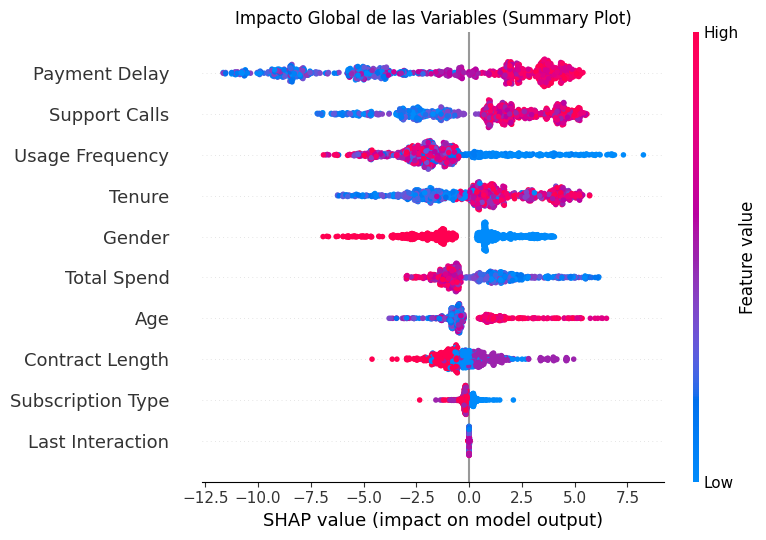

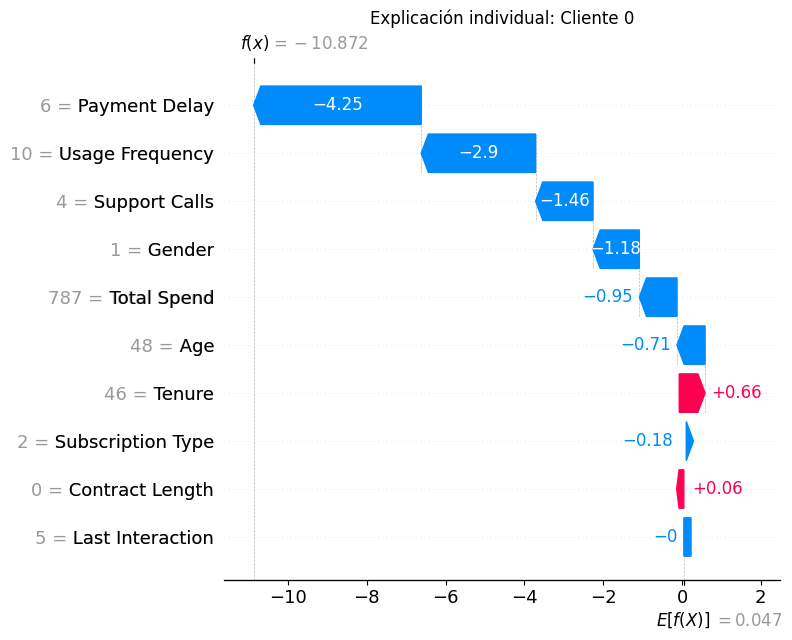

In [188]:
import shap

clientes_aleatorios = X_data_churn_filtrado.sample(1000)
model_booster = modelo_optimizado.get_booster()
explainer = shap.TreeExplainer(model_booster)

# Calculamos los valores SHAP para nuestros datos de prueba
shap_values = explainer.shap_values(clientes_aleatorios)

# --- GRÁFICO 1: Resumen Global (Summary Plot) ---
# Muestra qué variables impactan más y en qué dirección
plt.figure()
plt.title("Impacto Global de las Variables (Summary Plot)")
shap.summary_plot(shap_values, clientes_aleatorios, show=False)
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: Explicación Local (Waterfall / Force Plot para 1 cliente) ---
# Explicaremos por qué el modelo tomó la decisión para el Cliente #0 del set de prueba
# shap.plots.waterfall requiere un objeto Explanation, así que usamos el explainer general
explainer_obj = shap.Explainer(modelo_optimizado)(clientes_aleatorios)

plt.figure()
shap.plots.waterfall(explainer_obj[0], show=False)
plt.title("Explicación individual: Cliente 0")
plt.tight_layout()
plt.show()

# --- GRÁFICO 3: Dependencia (Dependence Plot) ---
# Muestra cómo cambia el riesgo de churn a medida que cambia una variable específica (ej. Llamadas_Soporte)
# plt.figure()
# shap.dependence_plot("Llamadas_Soporte", shap_values, clientes_aleatorios, show=False)
# plt.tight_layout()
# plt.show()